In [1]:
from astroquery.vizier import Vizier
import astropy.units as u
from astropy.table import Table ,vstack
from astropy.table import join
import matplotlib.pyplot as plt
from astropy.table import unique
import numpy as np
from astropy.io import fits
import scienceplots
from matplotlib import cm

import fitsio
import healpy as hp
import numpy as np
plt.style.use(['science', 'grid','notebook'])


/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
south_cuts_z = fitsio.read(f'/user/animesh.sah/FP_CUTS/south_cuts_only_5_only.fits')
north_cuts_z = fitsio.read(f'/user/animesh.sah/FP_CUTS/north_cuts_only_5_only.fits')


south_cuts_z_95 = fitsio.read(f'/user/animesh.sah/FP_CUTS/south_cuts_only_6_only.fits')
north_cuts_z_95 = fitsio.read(f'/user/animesh.sah/FP_CUTS/north_cuts_only_6_only.fits')




In [4]:
cuts  =[1,2,3,4,5,6,7,8,9]
north_cuts={}
south_cuts={}
for cut in cuts:
    north_cuts[cut] = fitsio.read(f'/user/animesh.sah/FP_CUTS/north_cuts_only_{cut}.fits')
    south_cuts[cut] = fitsio.read(f'/user/animesh.sah/FP_CUTS/south_cuts_only_{cut}.fits')
    south_cuts[cut] = south_cuts[cut][south_cuts[cut]['DEC']>-30]
    


In [5]:
for cut in cuts:
    south_cuts[cut] = south_cuts[cut][south_cuts[cut]['DEC']>-30]

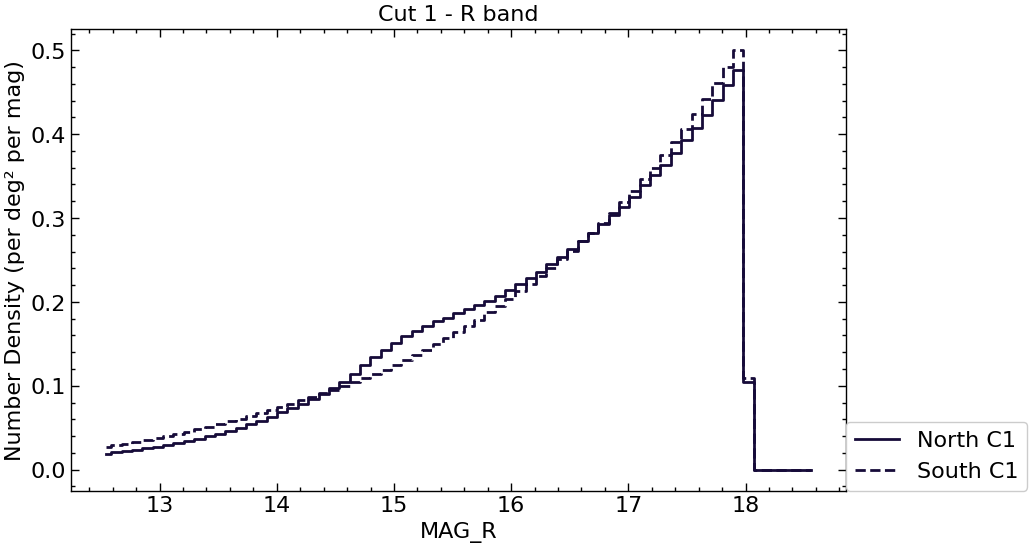

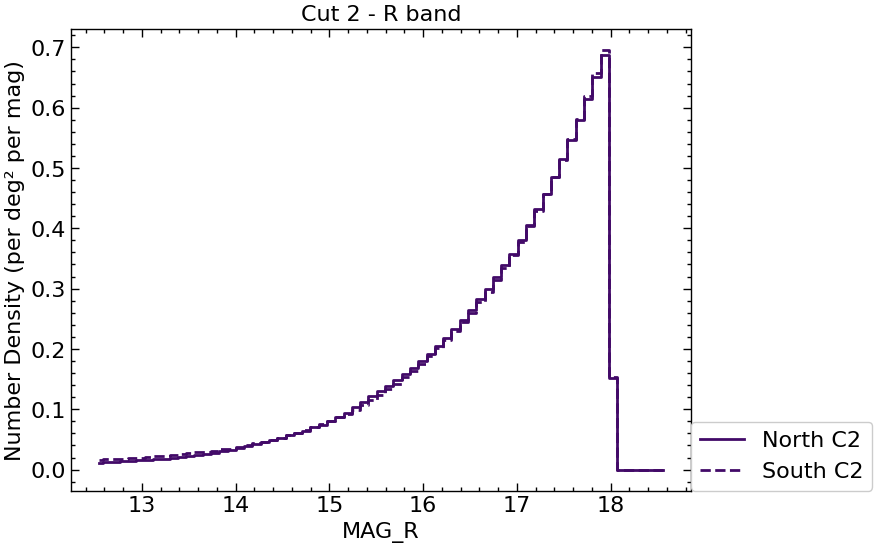

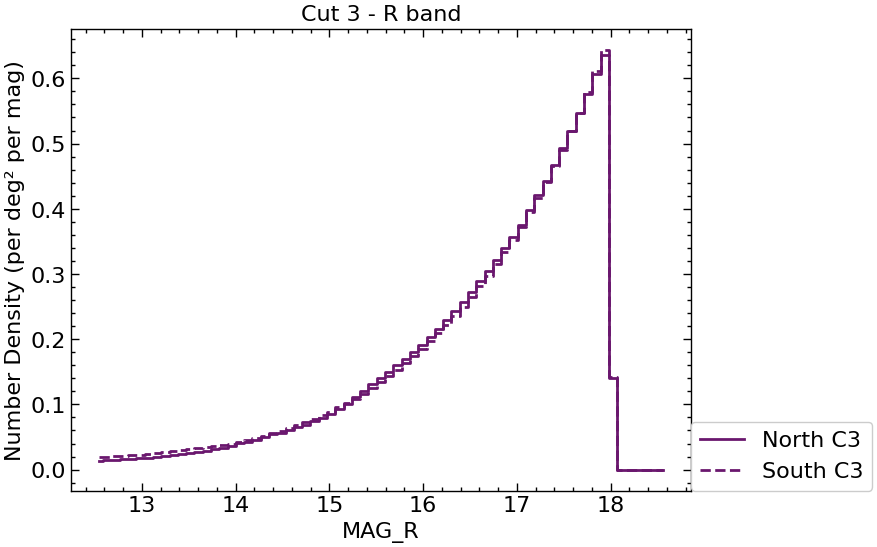

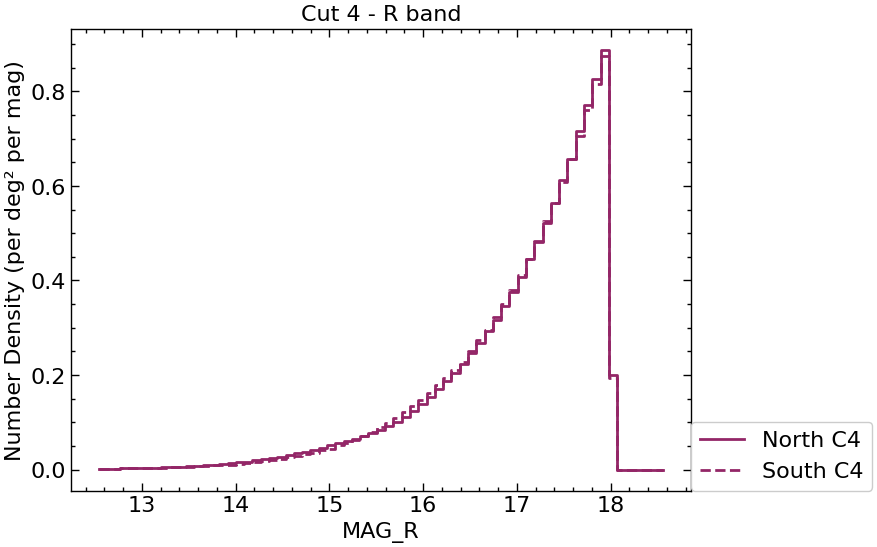

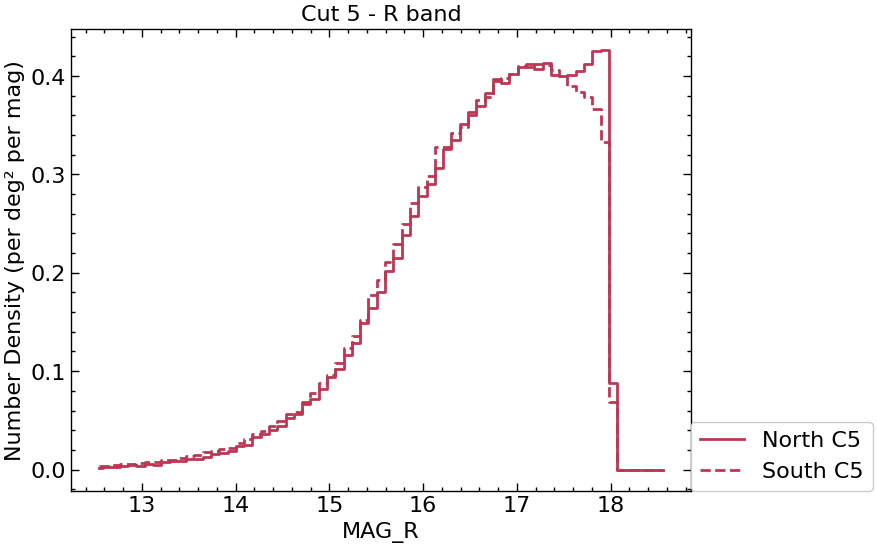

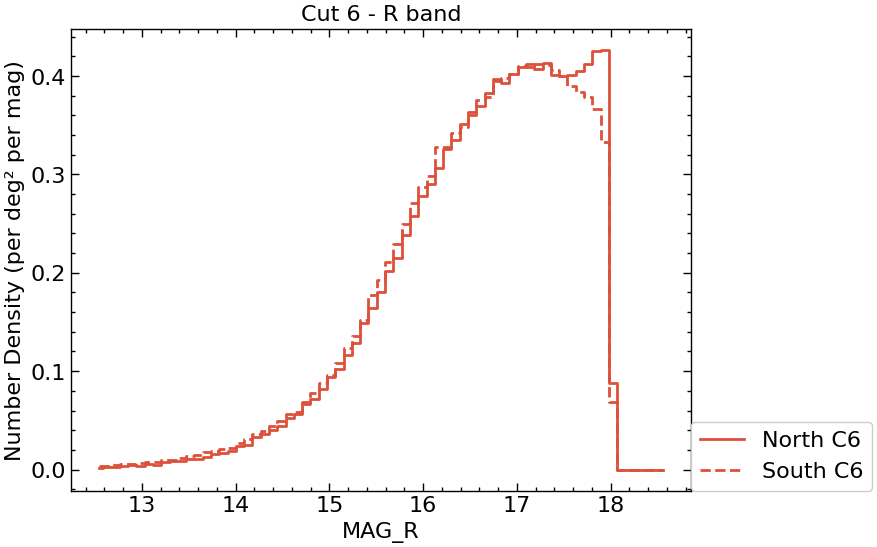

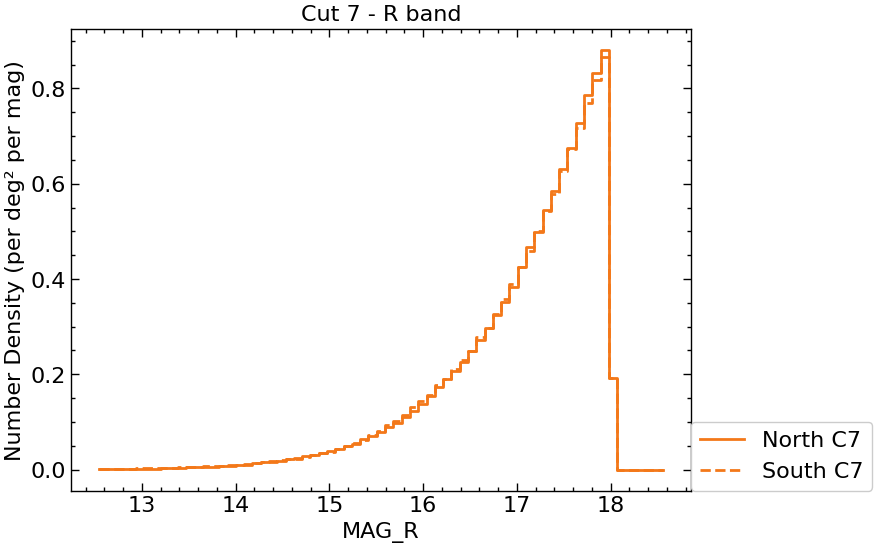

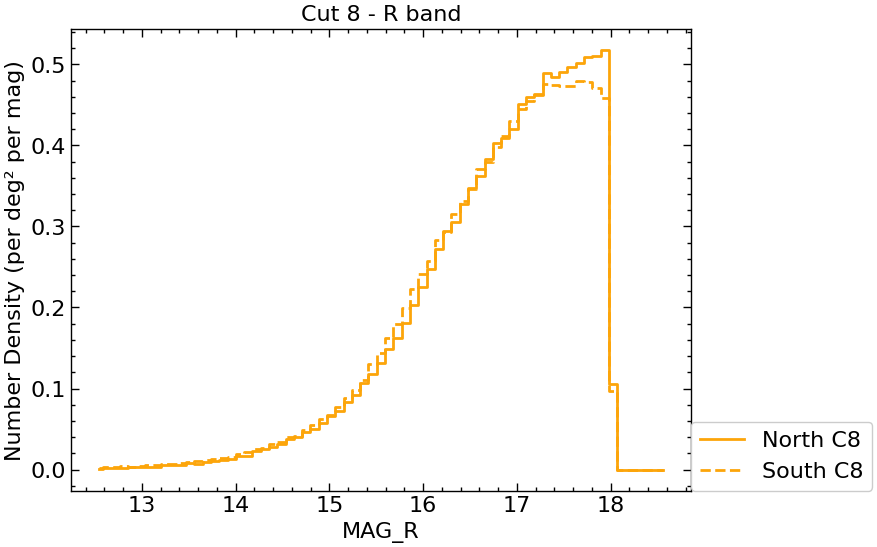

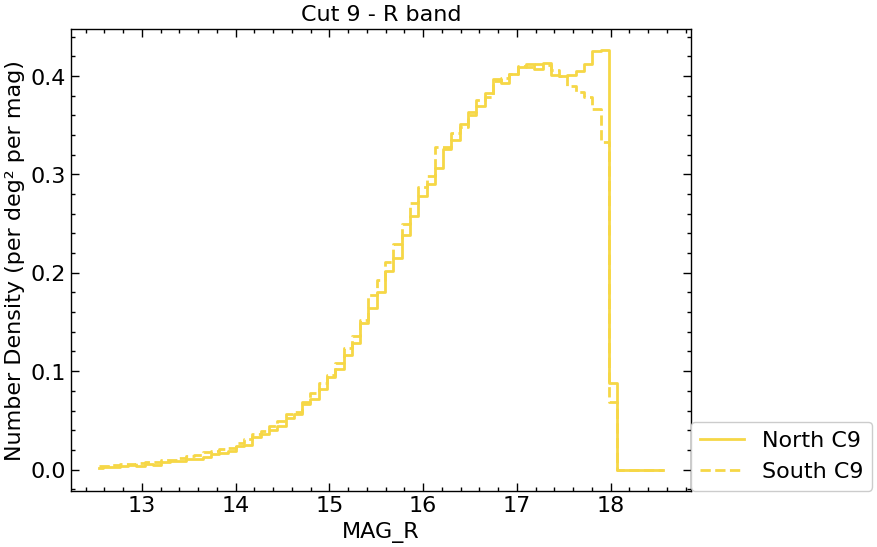

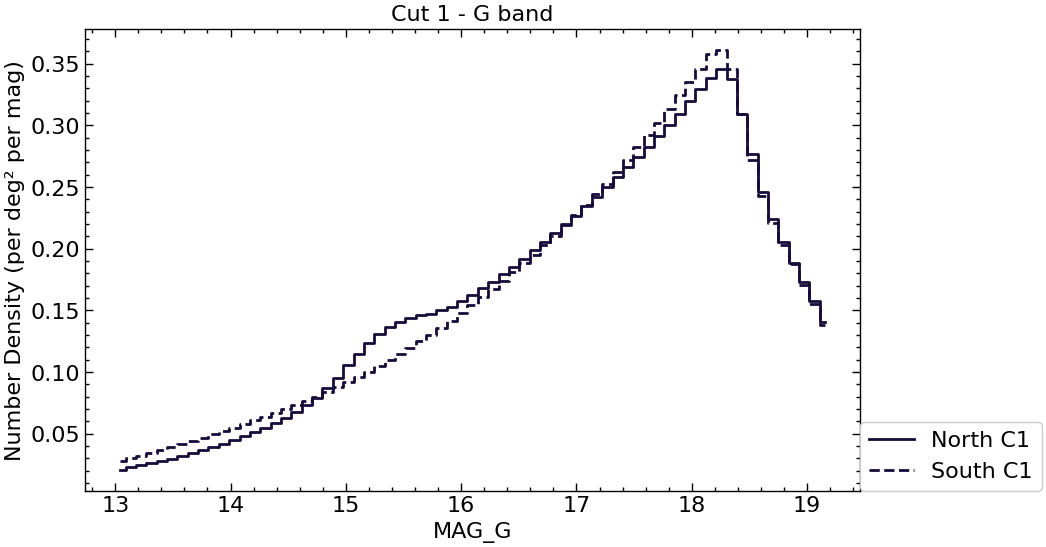

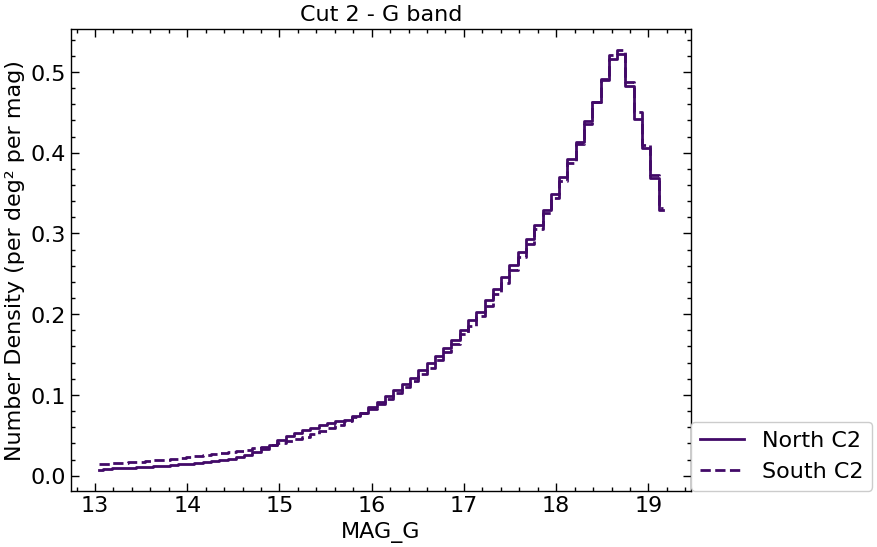

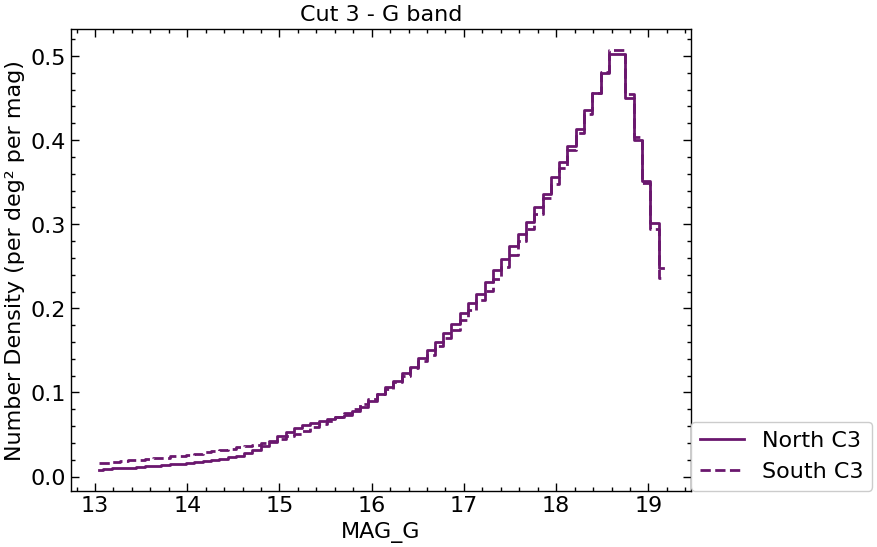

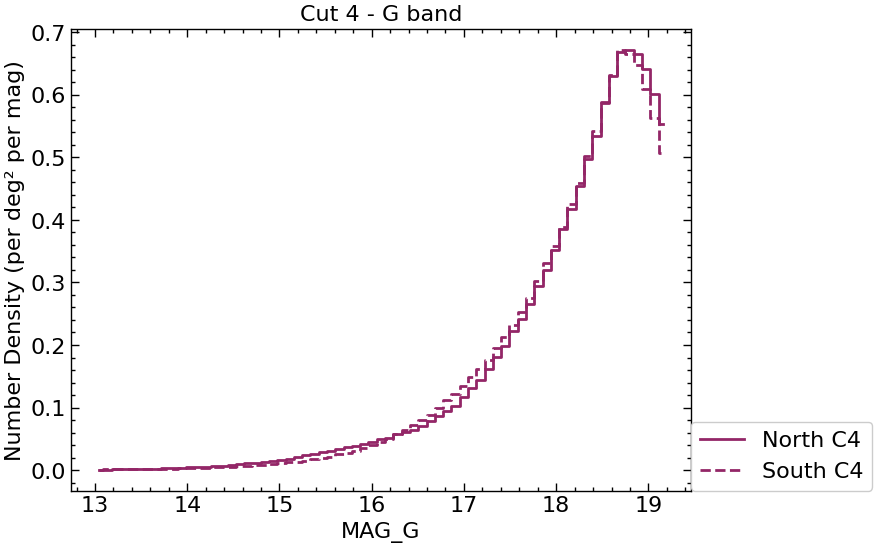

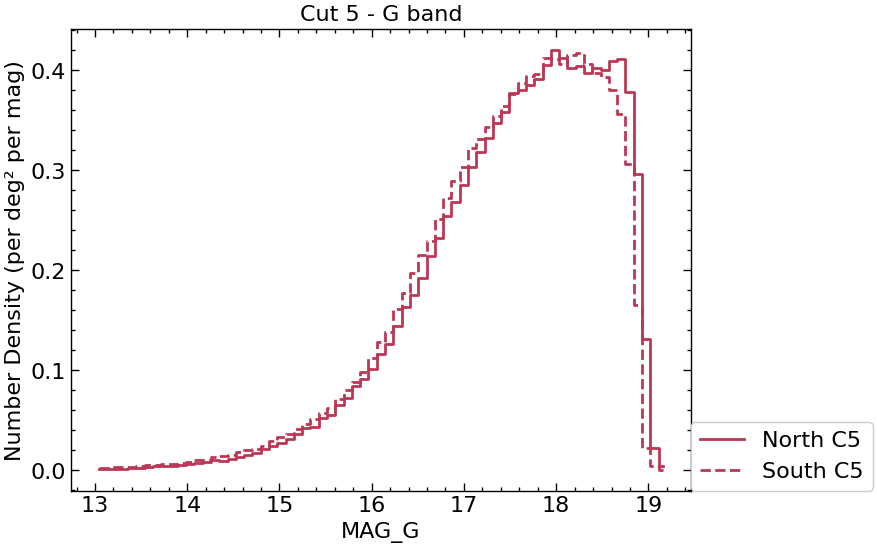

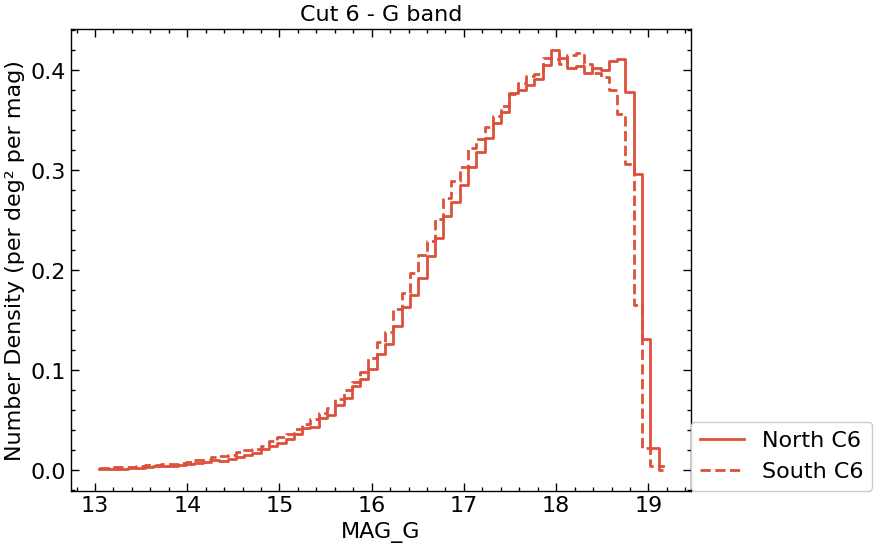

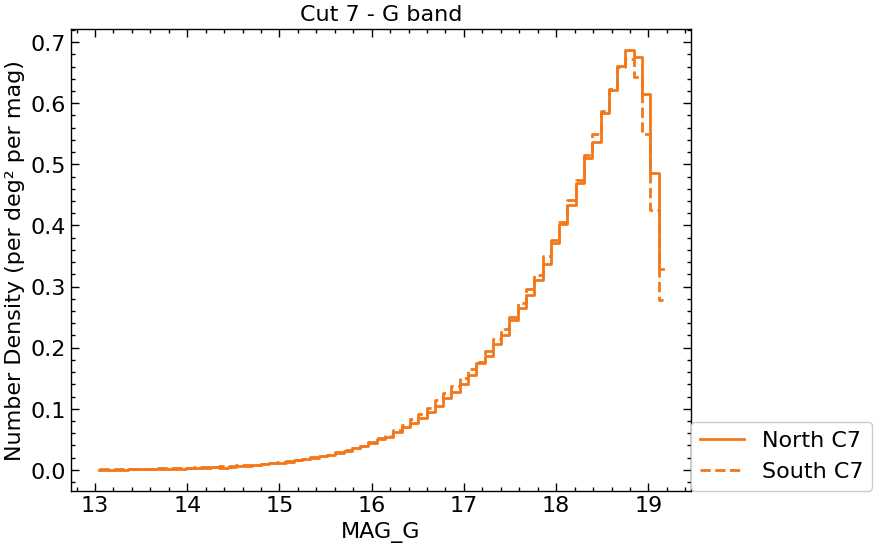

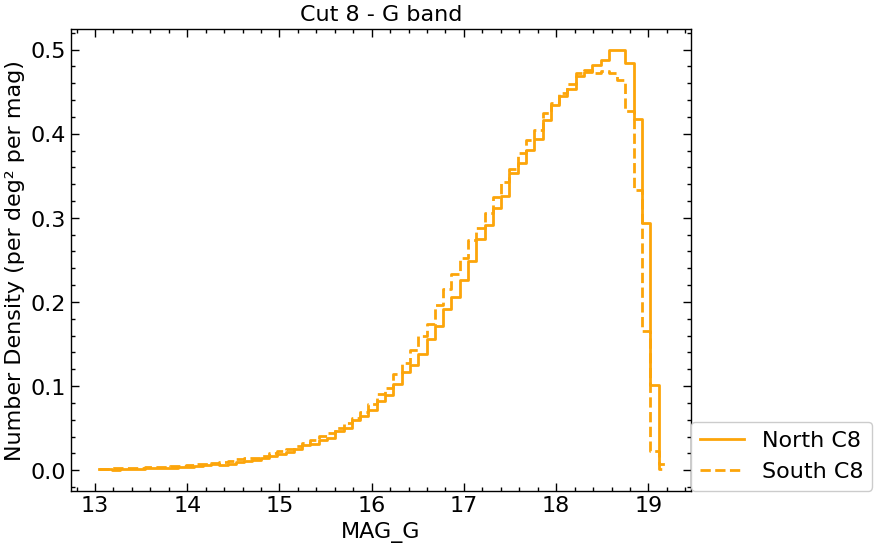

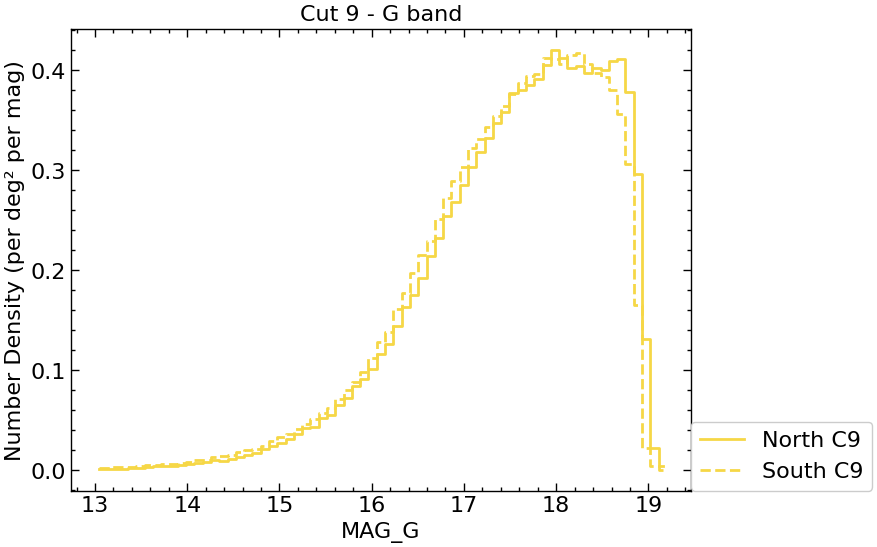

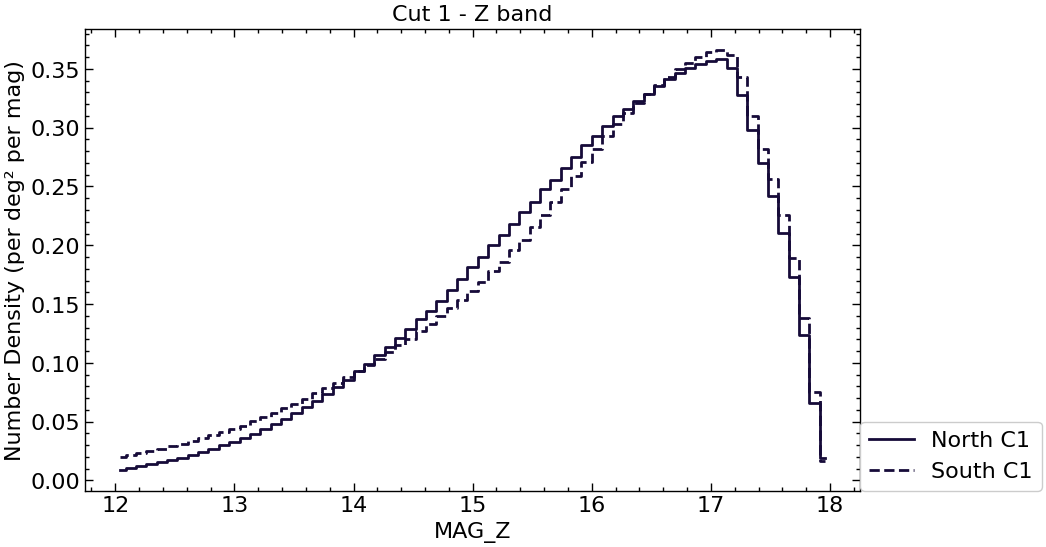

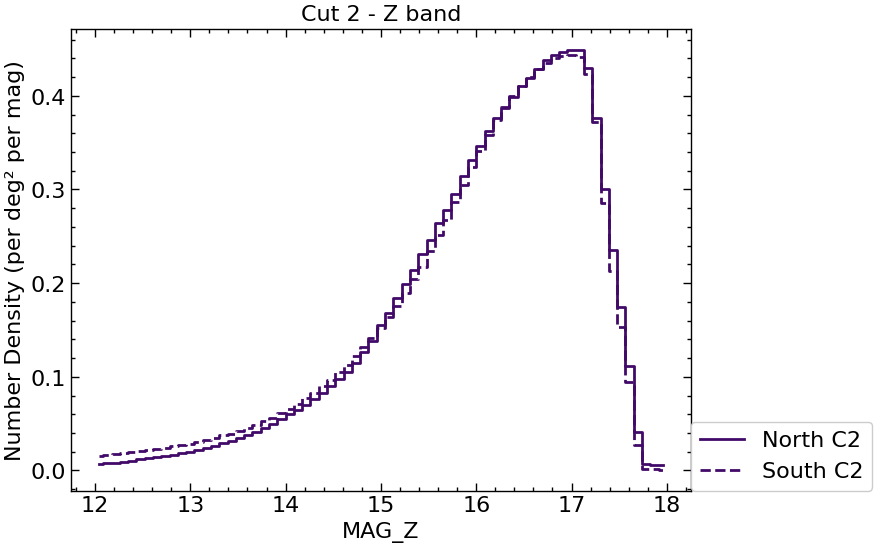

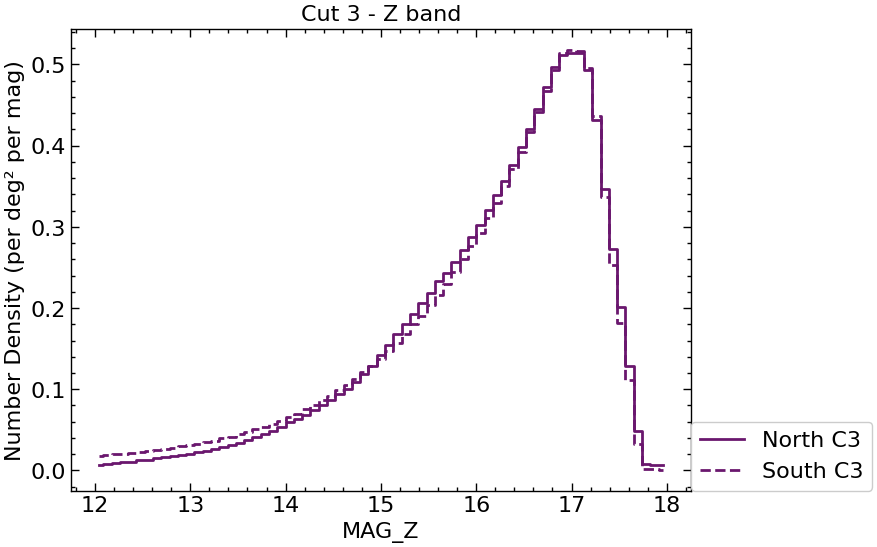

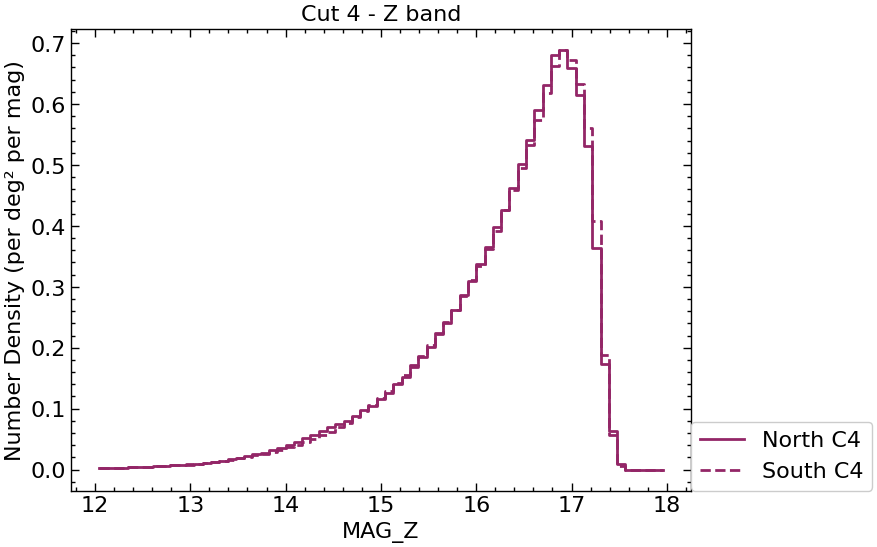

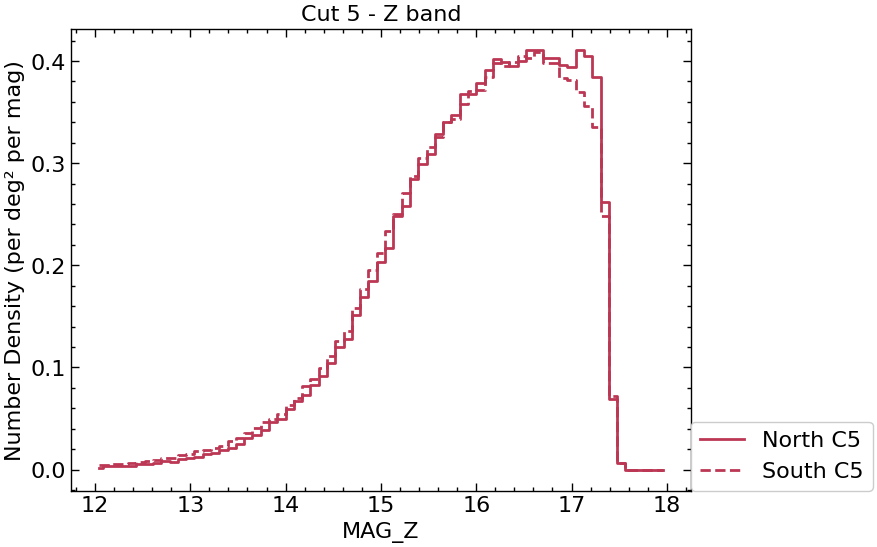

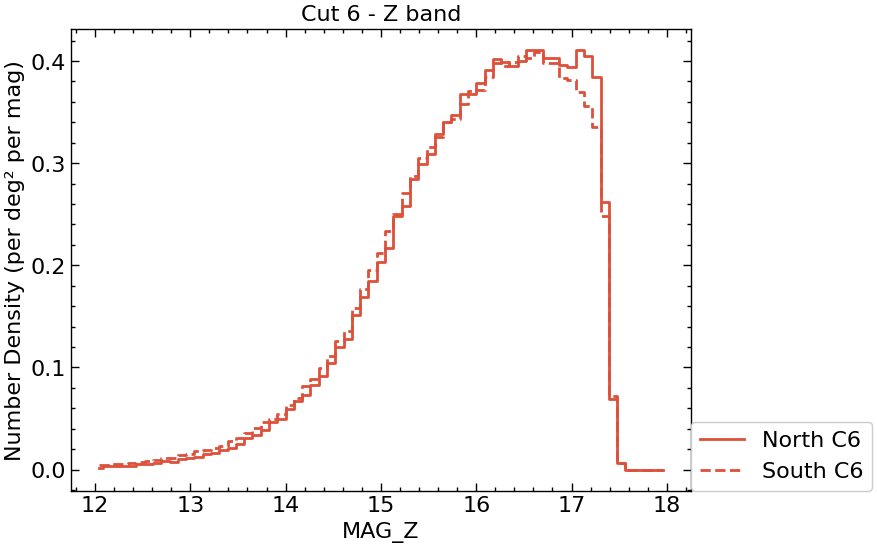

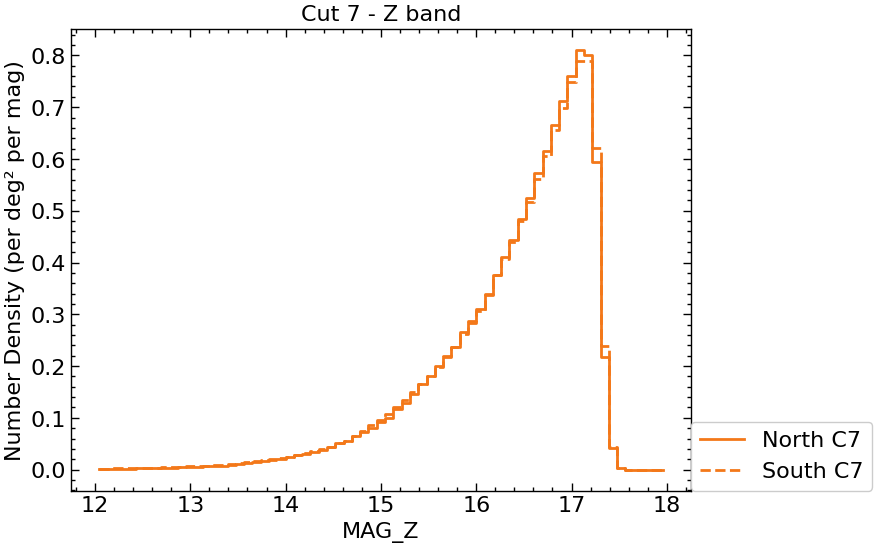

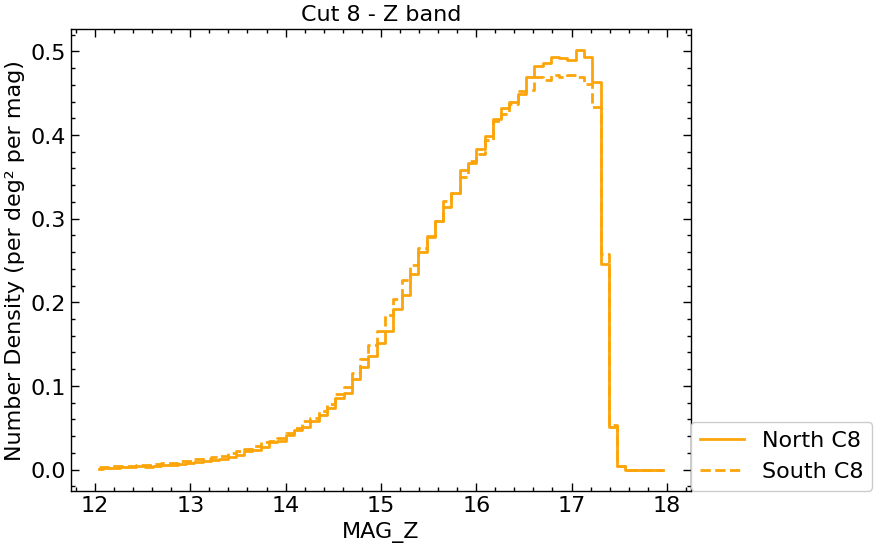

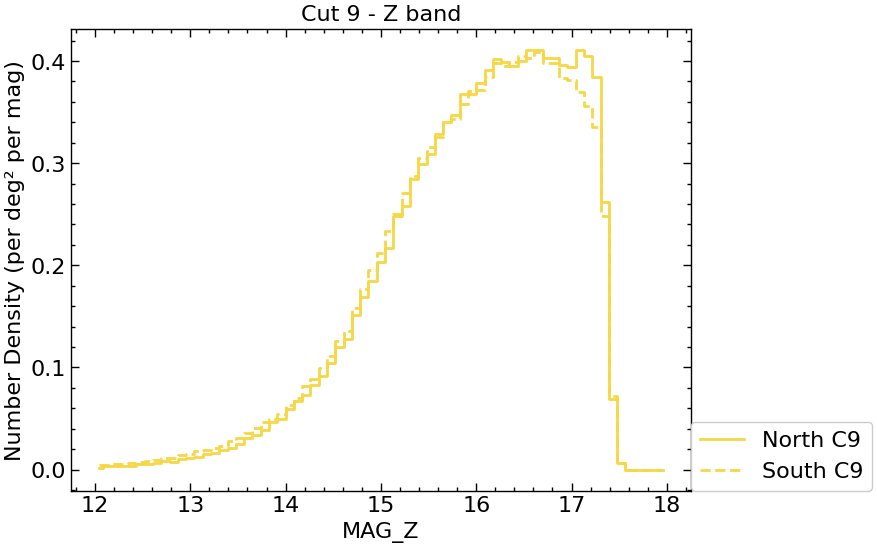

In [9]:
bands = ['R','G','Z']
cuts = [1,2,3,4,5,6,7,8,9]
colors1 = cm.YlGnBu(np.linspace(0.2, 0.9, len(cuts)))
colors2 = cm.inferno(np.linspace(0.1, 0.9, len(cuts)))
for band in bands:
    plt.figure(figsize=(10,6))

    for cut in cuts:

        if band =='R':
            bins_mag = np.linspace(12.5,18.6,70)
        elif band =='G':
            bins_mag = np.linspace(13,19.2,70)
        else:
            bins_mag = np.linspace(12,18,70)
        counts_north = np.histogram(north_cuts[cut][f'MAG_{band}'], bins=bins_mag, density=True)[0]
        counts_south = np.histogram(south_cuts[cut][f'MAG_{band}'], bins=bins_mag, density=True)[0]
        area_north=5167.3 
        area_south=12213.4
        bin_centers = (bins_mag[:-1] + bins_mag[1:]) / 2
        #plt.step(bin_centers, counts_north/area_north/np.diff(bins_mag)[0],color = colors2[cut-1], label=f'North C{cut}', where='mid')
        #plt.step(bin_centers, counts_south/area_south/np.diff(bins_mag)[0], color = colors2[cut-1], linestyle='--', label=f'South C{cut}', where='mid')

        plt.step(bin_centers, counts_north,color = colors2[cut-1], label=f'North C{cut}', where='mid')
        plt.step(bin_centers, counts_south, color = colors2[cut-1], linestyle='--', label=f'South C{cut}', where='mid')
        plt.xlabel(f'MAG_{band}')
        plt.ylabel('Number Density (per deg² per mag)')
        plt.legend(loc=(1,0))
        plt.title(f'Cut {cut} - {band} band')
        plt.grid()
        plt.show()
    


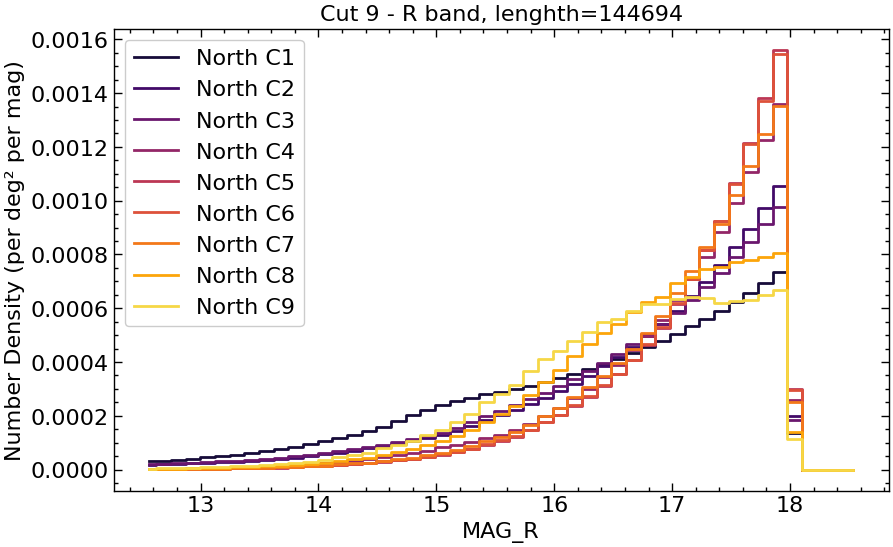

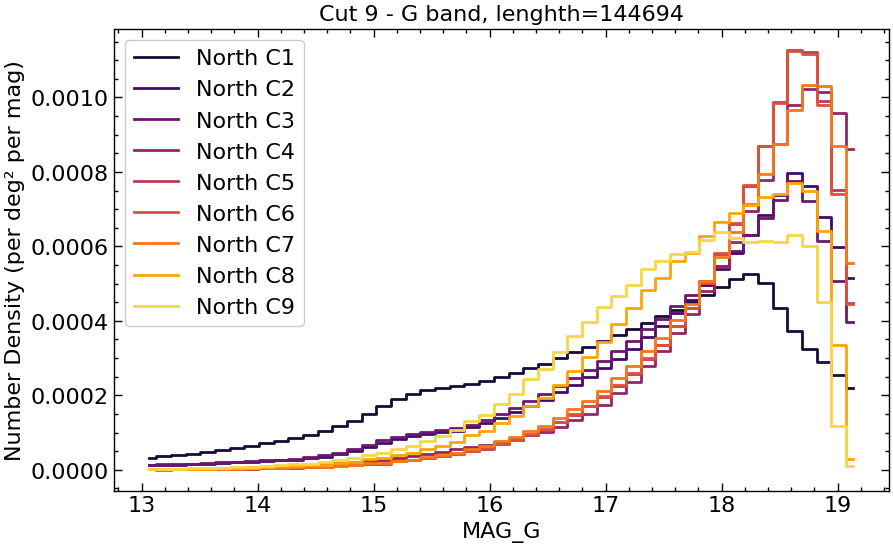

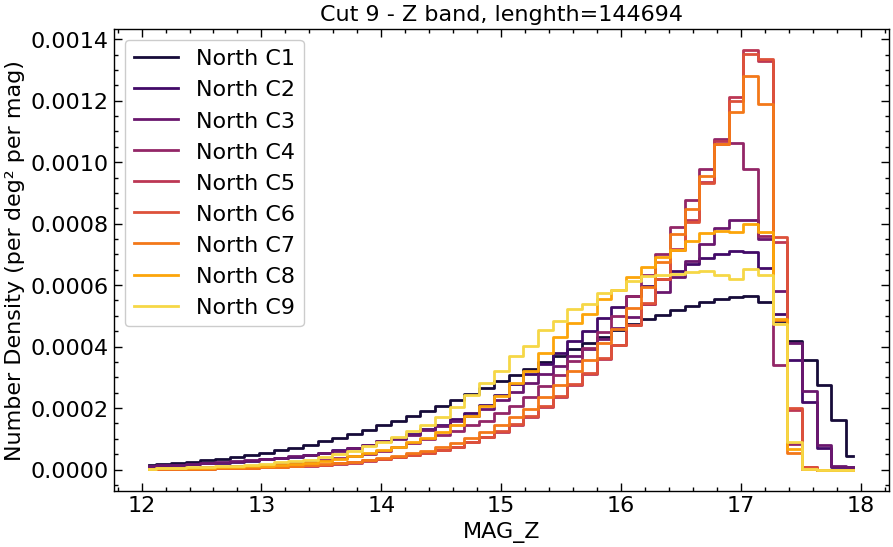

In [ ]:
bands = ['R','G','Z']
cuts=[1,2,3,4,5,6,7,8,9]

colors2 = cm.inferno(np.linspace(0.1, 0.9, len(cuts)))

for band in bands:
    plt.figure(figsize=(10,6))

    for cut in cuts:

        if band =='R':
            bins_mag = np.linspace(12.5,18.6,50)
        elif band =='G':
            bins_mag = np.linspace(13,19.2,50)
        else:
            bins_mag = np.linspace(12,18,50)
        counts_north = np.histogram(north_cuts[cut][f'MAG_{band}'], bins=bins_mag,density=True)[0]
        area_north=5167.3 

        area_south=12213.4
        bin_centers = (bins_mag[:-1] + bins_mag[1:]) / 2
        plt.step(bin_centers, counts_north/area_north/np.diff(bins_mag)[0], label=f'North C{cut}', where='mid', color = colors2[cut-1])
        plt.xlabel(f'MAG_{band}')
        plt.ylabel('Number Density (per deg² per mag)')
        plt.legend()
        plt.title(f'Cut {cut} - {band} band, lenghth={len(north_cuts[cut])}')
        plt.grid()
    plt.show()
    


In [33]:
len(south_cuts[1]), len(south_cuts[2]), len(south_cuts[3]), len(south_cuts[4])

(28199895, 11926332, 10029107, 3568064)

In [10]:
south_cuts_z = fitsio.read(f'/user/animesh.sah/FP_CUTS/south_cuts_only_5_only.fits')
north_cuts_z = fitsio.read(f'/user/animesh.sah/FP_CUTS/north_cuts_only_5_only.fits')


south_cuts_z_95 = fitsio.read(f'/user/animesh.sah/FP_CUTS/south_cuts_only_6_only.fits')
north_cuts_z_95 = fitsio.read(f'/user/animesh.sah/FP_CUTS/north_cuts_only_6_only.fits')



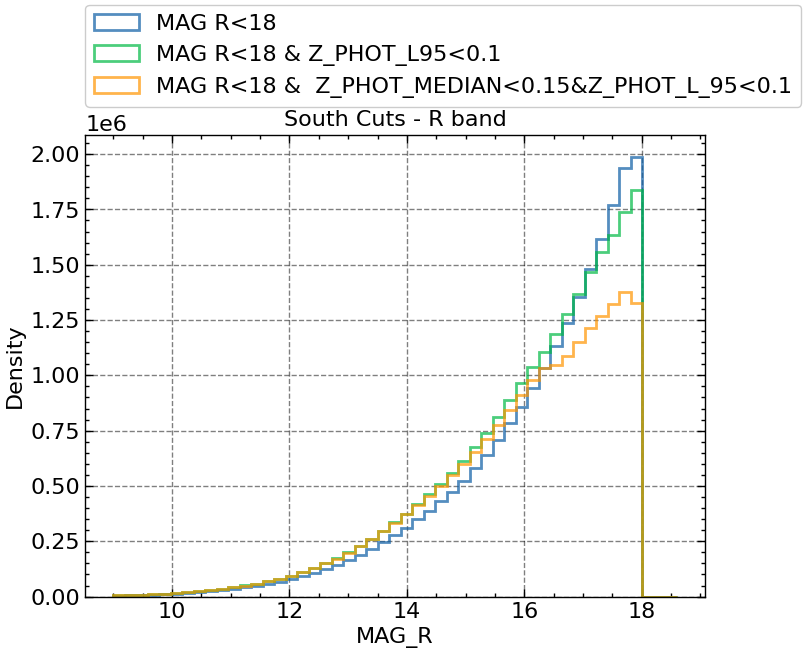

In [12]:
bins_r = np.linspace(9,18.6,50)
plt.hist(south_cuts[1]['MAG_R'], bins=bins_r,lw=2, density=False, label='MAG R<18', alpha=0.7,histtype='step')
plt.hist(south_cuts_z_95['MAG_R'], bins=bins_r,lw=2, density=False, label='MAG R<18 & Z_PHOT_L95<0.1', alpha=0.7,histtype='step')
plt.hist(south_cuts_z['MAG_R'], bins=bins_r,lw=2, density=False, label='MAG R<18 &  Z_PHOT_MEDIAN<0.15&Z_PHOT_L_95<0.1', alpha=0.7,histtype='step')

plt.title('South Cuts - R band')
plt.xlabel('MAG_R')
plt.ylabel('Density')
plt.legend(loc = (0,1.06))
plt.show()

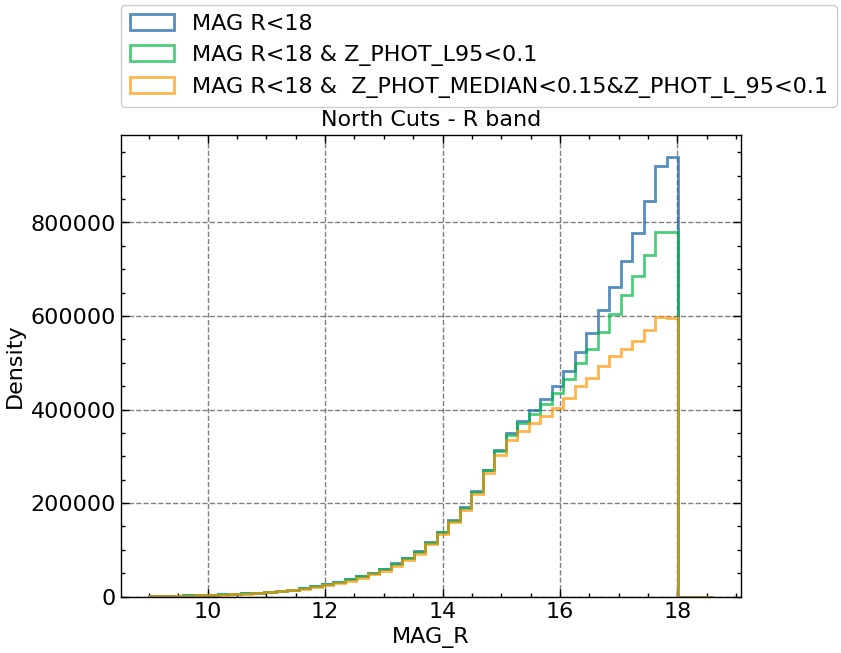

In [14]:

bins_r = np.linspace(9,18.6,50)
plt.hist(north_cuts[1]['MAG_R'], bins=bins_r,lw=2, density=False, label='MAG R<18', alpha=0.7,histtype='step')

plt.hist(north_cuts_z_95['MAG_R'], bins=bins_r,lw=2, density=False, label='MAG R<18 & Z_PHOT_L95<0.1', alpha=0.7,histtype='step')
plt.hist(north_cuts_z['MAG_R'], bins=bins_r,lw=2, density=False, label='MAG R<18 &  Z_PHOT_MEDIAN<0.15&Z_PHOT_L_95<0.1', alpha=0.7,histtype='step')

plt.title('North Cuts - R band')
plt.xlabel('MAG_R')
plt.ylabel('Density')
plt.legend(loc = (0,1.06))
plt.show()